In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive/AIProject

 scenic-main  'scenic-main (1).zip'   Untitled0.ipynb


In [ ]:
scenic_path = '/content/drive/MyDrive/AIProject/scenic-main'

In [ ]:
import sys
sys.path.append(scenic_path)

In [ ]:
from PIL import Image


In [ ]:
!pip install torch torchvision transformers pillow

from transformers import OwlViTProcessor, OwlViTForObjectDetection
from PIL import Image
import requests

# Load the model
processor = OwlViTProcessor.from_pretrained("google/owlvit-base-patch32")
model = OwlViTForObjectDetection.from_pretrained("google/owlvit-base-patch32")

# Load an image
from google.colab import files
uploaded = files.upload()  # pick your image
image_path = list(uploaded.keys())[0]
image = Image.open(image_path).convert("RGB")

# Define your query
text_query = ["tree", "bush"]

# Preprocess and run
inputs = processor(text=text_query, images=image, return_tensors="pt")
outputs = model(**inputs)

# outputs now has predicted boxes and labels


Saving free-nature-images.jpg to free-nature-images.jpg


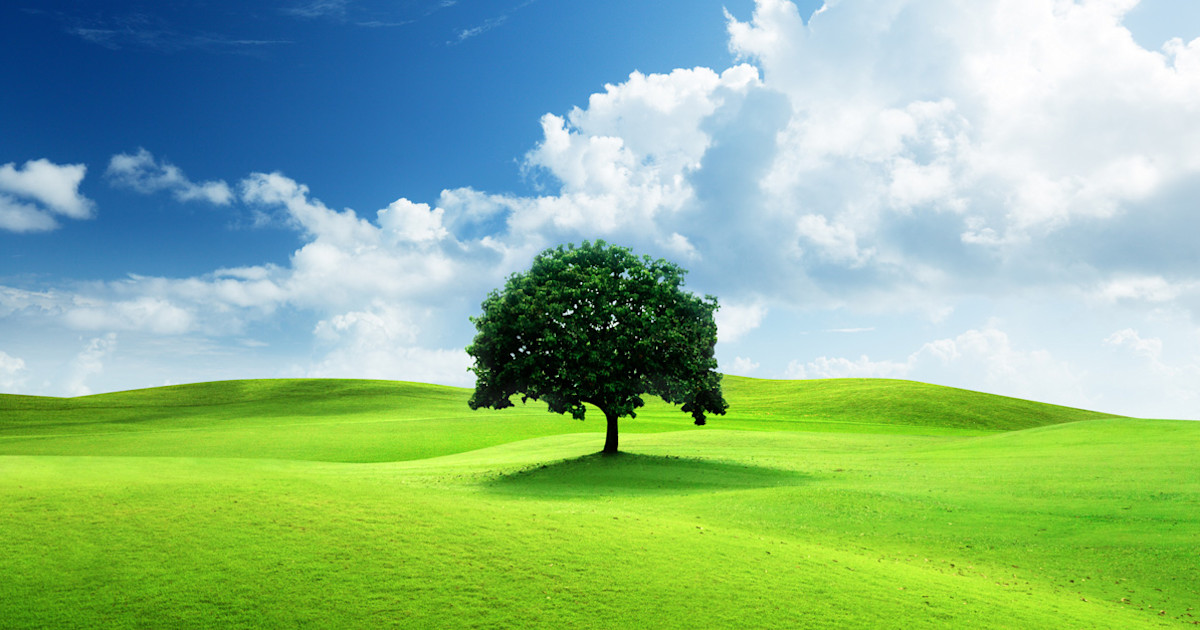

In [ ]:
from PIL import Image
from IPython.display import display  # <- Colab-friendly display

# Replace with your uploaded image filename
image_path = "free-nature-images.jpg"

# Open and convert to RGB
image = Image.open(image_path).convert("RGB")

# Display inline in Colab
display(image)


In [ ]:
from transformers import OwlViTProcessor, OwlViTForObjectDetection
import torch

# Load the processor and model
processor = OwlViTProcessor.from_pretrained("google/owlvit-base-patch32")
model = OwlViTForObjectDetection.from_pretrained("google/owlvit-base-patch32")

# Define your text query
text_query = ["tree", "Bush"]  # can be a list of multiple queries

# Preprocess image and text
inputs = processor(text=text_query, images=image, return_tensors="pt")

# Forward pass
outputs = model(**inputs)

# The outputs contain bounding boxes, scores, and labels
# You can print them or visualize next
print(outputs)


OwlViTObjectDetectionOutput(loss=None, loss_dict=None, logits=tensor([[[ -7.8157,  -9.6441],
         [-10.2461, -12.0945],
         [ -8.8914, -10.8205],
         ...,
         [-11.5873, -12.0201],
         [-10.9815, -11.2011],
         [-16.9606, -17.7775]]], grad_fn=<WhereBackward0>), pred_boxes=tensor([[[0.0750, 0.0667, 0.1492, 0.1351],
         [0.1415, 0.0512, 0.2330, 0.1006],
         [0.1118, 0.0233, 0.0594, 0.0422],
         ...,
         [0.8965, 0.9998, 0.2467, 0.1931],
         [0.9307, 0.9998, 0.1756, 0.1567],
         [0.9999, 0.9999, 0.2484, 0.1367]]], grad_fn=<SigmoidBackward0>), text_embeds=tensor([[[ 0.0884,  0.0103,  0.0116,  ..., -0.0025, -0.0449,  0.0763],
         [ 0.0678,  0.0259,  0.0019,  ...,  0.0124, -0.0506,  0.0892]]],
       grad_fn=<ViewBackward0>), image_embeds=tensor([[[[ 2.0102e-01, -3.2577e-01,  6.9289e-02,  ...,  1.0467e-02,
            8.0697e-01,  7.3183e-01],
          [ 2.2005e-01, -8.8113e-02,  8.0911e-02,  ..., -6.0133e-02,
            4.976

In [ ]:
import torch

# Boxes
boxes = outputs.pred_boxes[0]  # shape: [num_boxes, 4]

# Scores and labels
probs = outputs.logits[0].softmax(-1)  # softmax over classes
scores, labels = probs.max(-1)          # get max probability and corresponding class index

# If you want class names (assuming using processor.tokenizer)
classes = [processor.tokenizer.decode([label]) for label in labels]

# Print first 5 predictions for sanity check
for i in range(5):
    print(f"Box: {boxes[i]}, Class: {classes[i]}, Score: {scores[i].item():.2f}")


Box: tensor([0.0750, 0.0667, 0.1492, 0.1351], grad_fn=<SelectBackward0>), Class: !, Score: 0.86
Box: tensor([0.1415, 0.0512, 0.2330, 0.1006], grad_fn=<SelectBackward0>), Class: !, Score: 0.86
Box: tensor([0.1118, 0.0233, 0.0594, 0.0422], grad_fn=<SelectBackward0>), Class: !, Score: 0.87
Box: tensor([0.1818, 0.0294, 0.1199, 0.0594], grad_fn=<SelectBackward0>), Class: !, Score: 0.86
Box: tensor([0.3003, 0.1130, 0.6057, 0.2277], grad_fn=<SelectBackward0>), Class: !, Score: 0.92


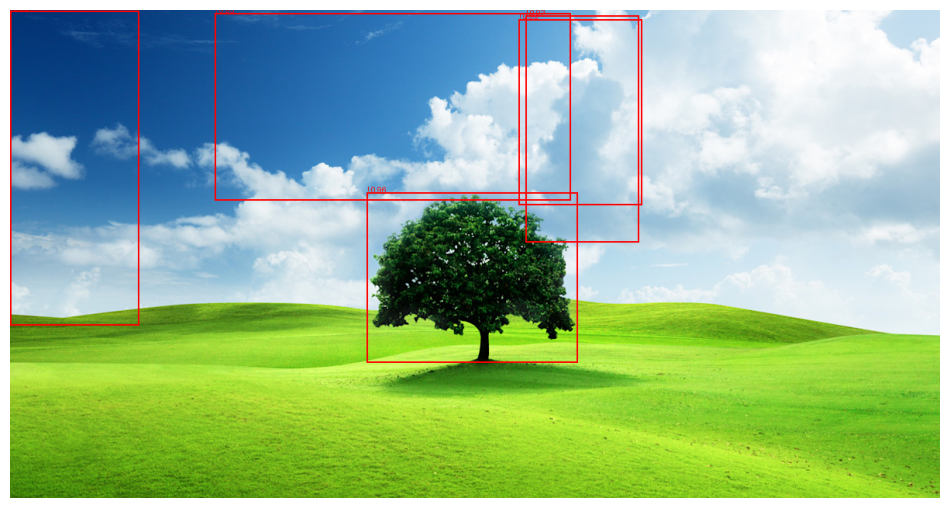

In [ ]:
import torch
import matplotlib.pyplot as plt
from PIL import ImageDraw, ImageFont

# Top-k boxes to visualize
top_k = 5
threshold = 0.5  # confidence threshold

# OwlViT outputs
boxes = outputs.pred_boxes[0]         # [num_boxes, 4]
logits = outputs.logits[0]            # [num_boxes, num_classes]

# Compute scores and labels
scores, labels = torch.max(torch.softmax(logits, dim=-1), dim=-1)
indices = torch.argsort(scores, descending=True)[:top_k]

image_with_boxes = image.copy()
draw = ImageDraw.Draw(image_with_boxes)
W, H = image.size

# Optional font
try:
    font = ImageFont.truetype("arial.ttf", 16)
except:
    font = ImageFont.load_default()

for i in indices:
    score = scores[i].item()
    if score < threshold:
        continue
    label_idx = labels[i].item()
    cls_name = processor.tokenizer.convert_ids_to_tokens([label_idx])[0]

    cx, cy, w, h = boxes[i].tolist()
    x0 = max((cx - w/2) * W, 0)
    y0 = max((cy - h/2) * H, 0)
    x1 = min((cx + w/2) * W, W)
    y1 = min((cy + h/2) * H, H)

    # Skip invalid boxes
    if x1 <= x0 or y1 <= y0:
        continue

    draw.rectangle([x0, y0, x1, y1], outline="red", width=2)
    draw.text((x0, y0-10), f"{cls_name} {score:.2f}", fill="red", font=font)

plt.figure(figsize=(12,8))
plt.imshow(image_with_boxes)
plt.axis('off')
plt.show()


This notebook introduces a confidence threshold to filter the model’s predictions. OWL-ViT outputs many candidate bounding boxes, each with a probability score representing how well the predicted object matches the text query. In the baseline code, every prediction is displayed, including low-confidence boxes that lead to visual clutter and false positives.

Here, we apply a confidence threshold of 0.5 (50%), meaning only boxes with at least 50% confidence are drawn. This improvement significantly cleans up the results by removing noisy, low-probability predictions. The threshold acts as a simple post-processing step that enhances interpretability and reduces incorrect detections without modifying the underlying model. This demonstrates how probability filtering can be used to improve object detection reliability when using open-vocabulary models like OWL-ViT.